In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize images
])

In [6]:
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

In [7]:
image, label = train_dataset[0]
print("Image shape:", image.shape)
print("Number of training samples:", len(train_dataset))

Image shape: torch.Size([1, 28, 28])
Number of training samples: 60000


In [8]:
image, label = test_dataset[0]
print("Image shape:", image.shape)
print("Number of testing samples:", len(test_dataset))

Image shape: torch.Size([1, 28, 28])
Number of testing samples: 10000


In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [10]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        # Convolution Layer 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)

        # Convolution Layer 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        # Activation Function
        self.relu = nn.ReLU()

        # Dropout
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):

        # First Conv Layer
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        # Second Conv Layer
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected Layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [11]:
from torchsummary import summary

# Initialize model
model = CNNClassifier()

# Move model to GPU if available
if torch.cuda.is_available():
    device = torch.device("cuda")
    model.to(device)

# Print model summary
print('Name:        ')
print('Register Number:       ')
summary(model, input_size=(1, 28, 28))

Name:        
Register Number:       
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Linear-7                  [-1, 128]         401,536
              ReLU-8                  [-1, 128]               0
           Dropout-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0

In [12]:
# Initialize model, loss function, and optimizer
model = CNNClassifier()

if torch.cuda.is_available():
    model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
## Step 3: Train the Model
def train_model(model, train_loader, num_epochs=3):

    model.train()

    for epoch in range(num_epochs):

        running_loss = 0.0

        for images, labels in train_loader:

            if torch.cuda.is_available():
                images, labels = images.to(device), labels.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            running_loss += loss.item()

        print('Name: Murali Krishna S')
        print('Register Number: 212223230129')
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

In [14]:
train_model(model, train_loader, num_epochs=10)

Name: Murali Krishna S
Register Number: 212223230129
Epoch [1/10], Loss: 0.1555
Name: Murali Krishna S
Register Number: 212223230129
Epoch [2/10], Loss: 0.0553
Name: Murali Krishna S
Register Number: 212223230129
Epoch [3/10], Loss: 0.0399
Name: Murali Krishna S
Register Number: 212223230129
Epoch [4/10], Loss: 0.0329
Name: Murali Krishna S
Register Number: 212223230129
Epoch [5/10], Loss: 0.0255
Name: Murali Krishna S
Register Number: 212223230129
Epoch [6/10], Loss: 0.0210
Name: Murali Krishna S
Register Number: 212223230129
Epoch [7/10], Loss: 0.0190
Name: Murali Krishna S
Register Number: 212223230129
Epoch [8/10], Loss: 0.0165
Name: Murali Krishna S
Register Number: 212223230129
Epoch [9/10], Loss: 0.0145
Name: Murali Krishna S
Register Number: 212223230129
Epoch [10/10], Loss: 0.0138


In [15]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            if torch.cuda.is_available():
                images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print('Name: ')
    print('Register Number: ')
    print(f'Test Accuracy: {accuracy:.4f}')
    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    print('Name: ')
    print('Register Number: ')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    # Print classification report
    print('Name: ')
    print('Register Number: ')
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

Name: 
Register Number: 
Test Accuracy: 0.9927
Name: 
Register Number: 


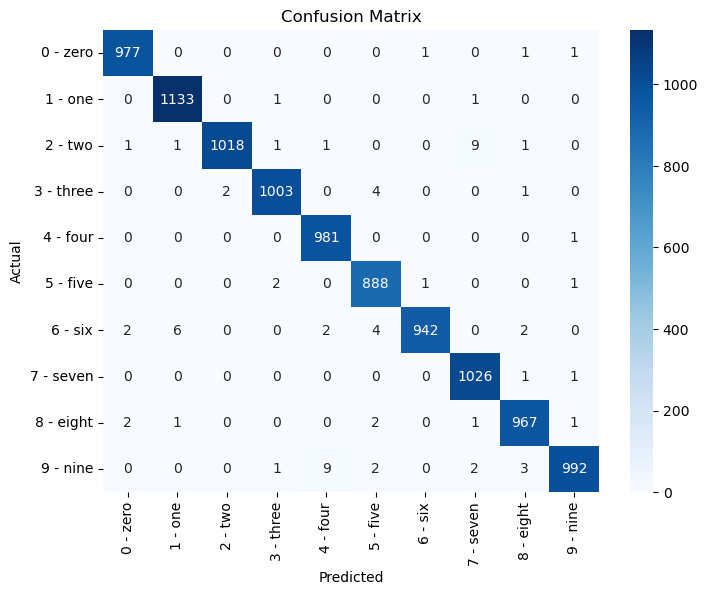

Name: 
Register Number: 
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      1.00      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [16]:
test_model(model, test_loader)

In [19]:
def predict_image(model, image_index, dataset):
    model.eval()
    image, label = dataset[image_index]
    if torch.cuda.is_available():
        image = image.to(device)

    with torch.no_grad():
        output = model(image.unsqueeze(0))
        _, predicted = torch.max(output, 1)

    class_names = [str(i) for i in range(10)]

    print('Name: Murali Krishna S')
    print('Register Number: 212223230129')
    plt.imshow(image.cpu().squeeze(), cmap="gray")
    plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted.item()]}')
    plt.axis("off")
    plt.show()
    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted.item()]}')

Name: Murali Krishna S
Register Number: 212223230129


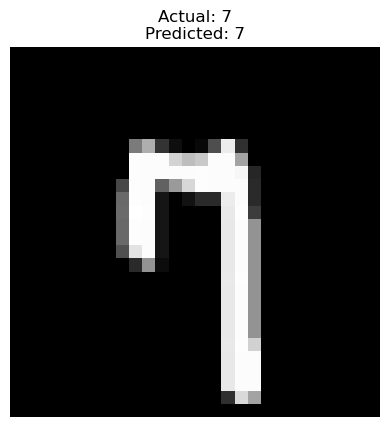

Actual: 7, Predicted: 7


In [20]:
predict_image(model, image_index=80, dataset=test_dataset)